# Hybrid SPECTER/BGE + TF-IDF Calibrated Pipeline for Climate Well-being Screening and Theme Annotation

This notebook is designed for your exact task:

1. **Input 1:** human-labelled training Excel file with title, abstract, Accept/Reject, and theme for accepted papers.  
2. **Input 2:** master Excel file of ~10k papers to annotate.  
3. **Output:** final master file with calibrated Accept/Reject prediction and theme annotation only for predicted accepted papers.

Important design decision: **this notebook intentionally excludes ClimateBERT and DeBERTa**. It also avoids unstable local generative-LLM fine-tuning. Instead, it uses a robust small-data strategy:

- scientific/semantic embeddings from **SPECTER / BGE / SciBERT-style encoders** as frozen feature extractors;
- word-level and character-level **TF-IDF** features;
- calibrated linear model ensemble for Accept/Reject;
- accepted-only theme classifier plus prototype smoothing for rare themes;
- threshold tuning with prevalence guardrails to avoid the previous over-acceptance failure.

This is usually more reliable for a dataset with only ~199 accepted examples than forcing a causal LLM to learn labels generatively.

In [1]:
# ============================================================
# 0. Optional dependency setup
# ============================================================
# Kaggle usually already has sklearn, pandas, numpy, scipy, matplotlib, openpyxl.
# HF embeddings are optional. If transformers/torch are unavailable or internet is off,
# the notebook will automatically fall back to TF-IDF-only mode.

# INSTALL_OPTIONAL_HF = True  # set True only if transformers/torch are missing

# if INSTALL_OPTIONAL_HF:
#     import sys, subprocess
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U', '--no-cache-dir',
#                            'transformers', 'accelerate', 'safetensors'])
#     print('Optional HF packages installed. Restart kernel if needed.')
# else:
#     print('Skipping package installation.')
import sys, subprocess

subprocess.run([
    sys.executable, "-m", "pip", "uninstall", "-y",
    "torch", "torchvision", "torchaudio",
    "torchao", "xformers", "flash-attn"
], check=False)

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--no-cache-dir", "--force-reinstall",
    "torch==2.5.1+cu121",
    "torchvision==0.20.1+cu121",
    "torchaudio==2.5.1+cu121",
    "--index-url", "https://download.pytorch.org/whl/cu121"
])

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--no-cache-dir", "-U",
    "transformers",
    "sentence-transformers",
    "scikit-learn",
    "pandas",
    "numpy",
    "openpyxl",
    "tqdm",
    "matplotlib",
    "scipy"
])

print("Now restart the Kaggle kernel/session before continuing.")

Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121
Found existing installation: torchaudio 2.5.1+cu121
Uninstalling torchaudio-2.5.1+cu121:
  Successfully uninstalled torchaudio-2.5.1+cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 305.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 303.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 327.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 281.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 351.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 293.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 367.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 357.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 142.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 274.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 359.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
s3fs 2026.2.0 requires fsspec==2026.2.0, but you have fsspec 2026.4.0 which is incompatible.
datasets 4.8.3 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.9 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.4 which is incompatible.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.3 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requ

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 373.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4
Now restart the Kaggle kernel/session before continuing.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
datasets 4.8.3 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.4.0 which is incompatible.
ydata-profiling 4.18.1 requires matplotlib<=3.10,>=3.5, but you have matplotlib 3.10.9 which is incompatible.
ydata-profiling 4.18.1 requires numpy<2.4,>=1.22, but you have numpy 2.4.6 which is incompatible.
ydata-profiling 4.18.1 requires pandas!=1.4.0,<3.0,>1.5, but you have pandas 3.0.3 which is incompatible.
ydata-profiling 4.18.1 requires scipy<1.17,>=1.8, but you have scipy 1.17.1 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
dop

In [3]:
# ============================================================
# 1. Imports and global configuration
# ============================================================
import os, re, json, math, gc, warnings, random, zipfile, unicodedata
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import scipy.sparse as sp

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.naive_bayes import ComplementNB
from sklearn.preprocessing import LabelEncoder, normalize
from sklearn.metrics import (
    average_precision_score, f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix, precision_recall_curve
)
from sklearn.isotonic import IsotonicRegression
from sklearn.decomposition import TruncatedSVD
from sklearn.utils.extmath import softmax
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ---------------------------
# File paths
# ---------------------------
# Update these two paths if your Kaggle dataset folder name is different.
TRAIN_FILE_CANDIDATES = [
    Path('/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx'),
    Path('/kaggle/input/Human labelled_DTU.xlsx'),
    Path('/mnt/data/Human labelled_DTU.xlsx'),
    Path('Human labelled_DTU.xlsx'),
]
MASTER_FILE_CANDIDATES = [
    Path('/kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx'),
    Path('/kaggle/input/Master file_10k papers.xlsx'),
    Path('/mnt/data/Master file_10k papers.xlsx'),
    Path('Master file_10k papers.xlsx'),
]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    raise FileNotFoundError('None of these files exist: ' + ', '.join(map(str, paths)))

TRAIN_FILE = first_existing(TRAIN_FILE_CANDIDATES)
MASTER_FILE = first_existing(MASTER_FILE_CANDIDATES)

OUTPUT_DIR = Path('/kaggle/working/hybrid_specter_bge_tfidf_outputs') if Path('/kaggle/working').exists() else Path('./hybrid_specter_bge_tfidf_outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR = OUTPUT_DIR / 'cache'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Experiment switches
# ---------------------------
N_FOLDS = 3
RUN_SVC = True              # strong but a little slower
RUN_SGD = True              # fast additional model diversity
RUN_NB = True               # strong lexical baseline
USE_HF_EMBEDDINGS = True    # if this fails, notebook continues with TF-IDF only
FORCE_CPU_EMBEDDINGS = False # True avoids CUDA issues completely, but slower
HF_BATCH_SIZE_GPU = 32
HF_BATCH_SIZE_CPU = 8
HF_MAX_LENGTH = 512

# Strictly exclude ClimateBERT and DeBERTa families.
EMBEDDING_MODELS = [
    'BAAI/bge-small-en-v1.5',  # compact strong semantic embedding model
    'allenai/specter',         # scientific-paper embedding model
    # 'allenai/scibert_scivocab_uncased',  # optional extra; slower, uncomment if needed
]
for m in EMBEDDING_MODELS:
    assert 'climatebert' not in m.lower() and 'deberta' not in m.lower(), f'Forbidden model selected: {m}'

# TF-IDF settings. These are intentionally strong for small labelled scientific text datasets.
WORD_MAX_FEATURES = 80000
CHAR_MAX_FEATURES = 50000
EMBEDDING_WEIGHT = 2.0

# Guardrails to avoid the old 47% over-acceptance failure.
ACCEPT_RATE_LOWER_MULT = 0.55
ACCEPT_RATE_UPPER_MULT = 1.85
ABSOLUTE_ACCEPT_RATE_CAP = 0.22
MIN_ACCEPT_RECALL_FOR_SCREENING = 0.45

print('Train file:', TRAIN_FILE)
print('Master file:', MASTER_FILE)
print('Output dir:', OUTPUT_DIR)

Train file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Human labelled_DTU.xlsx
Master file: /kaggle/input/datasets/hrithikmajumdar/climate-text-dataset/Master file_10k papers.xlsx
Output dir: /kaggle/working/hybrid_specter_bge_tfidf_outputs


In [4]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))
print(torch.cuda.get_device_capability(0))

x = torch.arange(8, device="cuda")
print(x)

2.5.1+cu121
12.1
Tesla P100-PCIE-16GB
(6, 0)
tensor([0, 1, 2, 3, 4, 5, 6, 7], device='cuda:0')


In [5]:
# ============================================================
# 2. Data loading and robust column handling
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ''
    x = str(x)
    x = unicodedata.normalize('NFKC', x)
    x = re.sub(r'\s+', ' ', x).strip()
    # Remove common copyright suffixes that add noise but not semantics.
    x = re.sub(r'©\s*\d{4}[^.]*\.?', ' ', x)
    x = re.sub(r'All rights reserved\.?', ' ', x, flags=re.I)
    x = re.sub(r'\s+', ' ', x).strip()
    return x


def load_training_file(path):
    """Load the labelled file even when it has no formal header."""
    raw = pd.read_excel(path, header=None)
    # In your current file, columns are:
    # annotator, id, authors, title, year, doi, link, abstract, decision, theme
    if raw.shape[1] >= 10:
        df = raw.iloc[:, :10].copy()
        df.columns = ['source', 'paper_id', 'authors', 'title', 'year', 'doi', 'url', 'abstract', 'decision', 'theme']
    else:
        # fallback for files with normal headers
        df2 = pd.read_excel(path)
        cols = {c.lower().strip(): c for c in df2.columns}
        def find_col(keys):
            for key in keys:
                for low, orig in cols.items():
                    if key in low:
                        return orig
            return None
        title_col = find_col(['title', 'article title', 'paper info'])
        abstract_col = find_col(['abstract'])
        decision_col = find_col(['decision', 'accept', 'screen', 'label'])
        theme_col = find_col(['theme', 'category', 'taxonomy'])
        id_col = find_col(['id', 'paper'])
        df = pd.DataFrame({
            'paper_id': df2[id_col] if id_col else np.arange(len(df2)),
            'title': df2[title_col] if title_col else '',
            'abstract': df2[abstract_col] if abstract_col else '',
            'decision': df2[decision_col] if decision_col else '',
            'theme': df2[theme_col] if theme_col else np.nan,
        })

    df['decision_norm'] = df['decision'].astype(str).str.strip().str.lower()
    # Remove duplicate/unusable rows; keep only gold Accept/Reject.
    df = df[df['decision_norm'].isin(['accept', 'reject'])].copy()
    df['accept_label'] = (df['decision_norm'] == 'accept').astype(int)
    df['title'] = df['title'].map(clean_text)
    df['abstract'] = df['abstract'].map(clean_text)
    df['theme'] = df['theme'].apply(lambda x: clean_text(x) if not pd.isna(x) else np.nan)
    df.loc[df['accept_label'] == 0, 'theme'] = np.nan
    df['text'] = ('Title: ' + df['title'].fillna('') + '\\nAbstract: ' + df['abstract'].fillna('')).map(clean_text)

    # Remove empty abstracts/titles if any.
    df = df[df['text'].str.len() > 20].copy().reset_index(drop=True)

    # Deduplicate hard duplicates by title+abstract; keep first label.
    before = len(df)
    df['dedup_key'] = (df['title'].str.lower().str[:250] + ' || ' + df['abstract'].str.lower().str[:500])
    df = df.drop_duplicates('dedup_key').copy().reset_index(drop=True)
    after = len(df)
    print(f'Training rows after filtering/dedup: {after} (removed {before-after})')
    return df


def load_master_file(path):
    df = pd.read_excel(path)
    cols = {c.lower().strip(): c for c in df.columns}
    def find_col(keys):
        for key in keys:
            for low, orig in cols.items():
                if key in low:
                    return orig
        return None
    title_col = find_col(['article title', 'title'])
    abstract_col = find_col(['abstract'])
    id_col = find_col(['id_new', 'id_old', 'id'])
    if title_col is None or abstract_col is None:
        raise ValueError(f'Could not detect title/abstract columns. Columns found: {list(df.columns)}')
    out = df.copy()
    out['_row_id'] = np.arange(len(out))
    out['_paper_id'] = out[id_col].astype(str) if id_col else out['_row_id'].astype(str)
    out['_title'] = out[title_col].map(clean_text)
    out['_abstract'] = out[abstract_col].map(clean_text)
    out['_text'] = ('Title: ' + out['_title'].fillna('') + '\\nAbstract: ' + out['_abstract'].fillna('')).map(clean_text)
    return out, {'title_col': title_col, 'abstract_col': abstract_col, 'id_col': id_col}

train_df = load_training_file(TRAIN_FILE)
master_df, master_cols = load_master_file(MASTER_FILE)

print('\\nTraining shape:', train_df.shape)
print('Master shape:', master_df.shape)
print('Master detected columns:', master_cols)
print('\\nAccept/Reject distribution:')
print(train_df['accept_label'].value_counts())
print('Accept rate:', train_df['accept_label'].mean())
print('\\nTheme distribution:')
print(train_df.loc[train_df.accept_label == 1, 'theme'].value_counts())

Training rows after filtering/dedup: 1720 (removed 0)
\nTraining shape: (1720, 14)
Master shape: (10176, 13)
Master detected columns: {'title_col': 'Article Title', 'abstract_col': 'Abstract', 'id_col': 'ID_New'}
\nAccept/Reject distribution:
accept_label
0    1521
1     199
Name: count, dtype: int64
Accept rate: 0.11569767441860465
\nTheme distribution:
theme
Climate change mitigation options & Well-being       84
Empowering People & Governance, Policy               31
Implemented mitigation Options and Well-being        21
Well-being, Community & Societal Systems Thinking    11
SDGs and Well-being                                  10
Equity, Social Justice, Just Transition               8
Better Well-being Metric                              7
Ecosystem & Non-human Well-being                      6
Integrated Responses and Well-being                   6
Access to Services and Wellbeing                      6
Well-being Loss from Climate Mitigation               5
Systems Thinking- Mod

In [6]:
# ============================================================
# 3. Theme encoding and helper functions
# ============================================================
accepted_theme_df = train_df[(train_df['accept_label'] == 1) & train_df['theme'].notna()].copy()
if accepted_theme_df.empty:
    raise ValueError('No accepted rows with theme labels were found.')

theme_encoder = LabelEncoder()
theme_encoder.fit(accepted_theme_df['theme'].astype(str))
theme_names = list(theme_encoder.classes_)
theme2id = {t: i for i, t in enumerate(theme_names)}
id2theme = {i: t for t, i in theme2id.items()}
train_df['theme_id'] = train_df['theme'].map(theme2id)
N_THEMES = len(theme_names)

with open(OUTPUT_DIR / 'theme_mapping.json', 'w') as f:
    json.dump({'theme2id': theme2id, 'id2theme': id2theme}, f, indent=2)

print('Number of themes:', N_THEMES)
for i, t in id2theme.items():
    print(f'{i:02d}: {t}  | n={(train_df.theme_id == i).sum()}')


def safe_array(x, fill=0.0):
    x = np.asarray(x, dtype=np.float64)
    return np.nan_to_num(x, nan=fill, posinf=fill, neginf=fill)


def safe_proba_binary(model, X):
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)
        if p.ndim == 2 and p.shape[1] == 2:
            # Align class 1 if available
            classes = getattr(model, 'classes_', np.array([0,1]))
            if 1 in classes:
                return safe_array(p[:, list(classes).index(1)])
            return safe_array(p[:, -1])
    if hasattr(model, 'decision_function'):
        s = model.decision_function(X)
        return 1 / (1 + np.exp(-np.clip(s, -30, 30)))
    pred = model.predict(X)
    return safe_array(pred)


def align_multiclass_proba(model, X, n_classes):
    if hasattr(model, 'predict_proba'):
        p = model.predict_proba(X)
        classes = getattr(model, 'classes_', np.arange(p.shape[1]))
        out = np.zeros((X.shape[0], n_classes), dtype=np.float64)
        for j, cls in enumerate(classes):
            if int(cls) < n_classes:
                out[:, int(cls)] = p[:, j]
        row_sum = out.sum(axis=1, keepdims=True)
        out = np.divide(out, np.maximum(row_sum, 1e-12))
        return safe_array(out)
    pred = model.predict(X).astype(int)
    out = np.zeros((X.shape[0], n_classes), dtype=np.float64)
    out[np.arange(len(pred)), pred] = 1.0
    return out


def binary_metrics(y_true, p, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    p = safe_array(p, fill=float(np.nanmean(p) if np.isfinite(p).any() else y_true.mean()))
    pred = (p >= threshold).astype(int)
    ap = average_precision_score(y_true, p) if len(np.unique(y_true)) > 1 else np.nan
    macro = f1_score(y_true, pred, average='macro', zero_division=0)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, pred, labels=[0,1], zero_division=0)
    return {
        'AP': float(ap),
        'macro_f1': float(macro),
        'reject_precision': float(prec[0]), 'reject_recall': float(rec[0]), 'reject_f1': float(f1[0]),
        'accept_precision': float(prec[1]), 'accept_recall': float(rec[1]), 'accept_f1': float(f1[1]),
        'pred_accept_rate': float(pred.mean()),
        'threshold': float(threshold),
    }


def tune_accept_threshold(y_true, p, target_rate=None):
    y_true = np.asarray(y_true).astype(int)
    p = safe_array(p, fill=float(y_true.mean()))
    if target_rate is None:
        target_rate = float(y_true.mean())
    lower = max(0.01, target_rate * ACCEPT_RATE_LOWER_MULT)
    upper = min(ABSOLUTE_ACCEPT_RATE_CAP, max(target_rate * ACCEPT_RATE_UPPER_MULT, target_rate + 0.03))
    rows = []
    for t in np.linspace(0.01, 0.99, 197):
        m = binary_metrics(y_true, p, t)
        pr = m['pred_accept_rate']
        prevalence_penalty = abs(pr - target_rate) / max(target_rate, 1e-6)
        constraint_bonus = 0.0
        if lower <= pr <= upper:
            constraint_bonus += 0.08
        if m['accept_recall'] >= MIN_ACCEPT_RECALL_FOR_SCREENING:
            constraint_bonus += 0.04
        # Balanced objective: strong macro-F1, good Accept F1, but avoid rate explosion.
        objective = (0.58*m['macro_f1'] + 0.20*m['accept_f1'] + 0.10*m['accept_precision'] + 0.08*m['accept_recall']
                     - 0.18*prevalence_penalty + constraint_bonus)
        m['objective'] = float(objective)
        rows.append(m)
    grid = pd.DataFrame(rows).sort_values('objective', ascending=False).reset_index(drop=True)
    return grid.iloc[0].to_dict(), grid


def theme_metrics(y_true, probs):
    y_true = np.asarray(y_true).astype(int)
    probs = safe_array(probs)
    pred = probs.argmax(axis=1)
    macro = f1_score(y_true, pred, average='macro', zero_division=0)
    weighted = f1_score(y_true, pred, average='weighted', zero_division=0)
    coverage = len(np.unique(pred))
    return {
        'theme_macro_f1': float(macro),
        'theme_weighted_f1': float(weighted),
        'theme_coverage': int(coverage),
        'n_themes': int(probs.shape[1]),
    }


def prior_correct(probs, class_counts, alpha=0.0):
    probs = safe_array(probs)
    if alpha <= 0:
        row_sum = probs.sum(axis=1, keepdims=True)
        return probs / np.maximum(row_sum, 1e-12)
    counts = np.asarray(class_counts, dtype=np.float64) + 1.0
    prior = counts / counts.sum()
    adjusted = probs / np.power(prior[None, :], alpha)
    adjusted = np.clip(adjusted, 1e-12, None)
    return adjusted / adjusted.sum(axis=1, keepdims=True)

Number of themes: 12
00: Access to Services and Wellbeing  | n=6
01: Better Well-being Metric  | n=7
02: Climate change mitigation options & Well-being  | n=84
03: Ecosystem & Non-human Well-being  | n=6
04: Empowering People & Governance, Policy  | n=31
05: Equity, Social Justice, Just Transition  | n=8
06: Implemented mitigation Options and Well-being  | n=21
07: Integrated Responses and Well-being  | n=6
08: SDGs and Well-being  | n=10
09: Systems Thinking- Modelling and Supply Chain  | n=3
10: Well-being Loss from Climate Mitigation  | n=5
11: Well-being, Community & Societal Systems Thinking  | n=11


In [7]:
# ============================================================
# 4. Optional frozen HF embeddings: BGE/SPECTER/SciBERT-style features
# ============================================================
# These are frozen feature extractors, not fine-tuned LLMs. If CUDA is broken,
# this section falls back to CPU. If HF download fails, the whole pipeline still runs with TF-IDF.

all_texts = pd.concat([train_df['text'], master_df['_text']], ignore_index=True).tolist()
n_train = len(train_df)
n_master = len(master_df)


def detect_embedding_device():
    if FORCE_CPU_EMBEDDINGS:
        return 'cpu'
    try:
        import torch
        if torch.cuda.is_available():
            try:
                _ = torch.arange(4, device='cuda')
                print('CUDA sanity check passed for embeddings:', torch.cuda.get_device_name(0))
                return 'cuda'
            except Exception as e:
                print('CUDA exists but failed sanity check. Falling back to CPU:', repr(e))
                return 'cpu'
        return 'cpu'
    except Exception as e:
        print('Torch unavailable. Embeddings disabled:', repr(e))
        return None


def mean_pool(last_hidden, attention_mask):
    import torch
    mask = attention_mask.unsqueeze(-1).expand(last_hidden.size()).float()
    return (last_hidden * mask).sum(1) / torch.clamp(mask.sum(1), min=1e-9)


def embed_with_hf_model(texts, model_name, cache_name, device='cpu'):
    cache_path = CACHE_DIR / f'{cache_name}.npy'
    if cache_path.exists():
        print('Loading cached embeddings:', cache_path)
        return np.load(cache_path)
    import torch
    from transformers import AutoTokenizer, AutoModel
    print(f'Loading embedding model: {model_name} on {device}')
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name)
    model.eval().to(device)
    bs = HF_BATCH_SIZE_GPU if device == 'cuda' else HF_BATCH_SIZE_CPU
    embs = []
    for start in range(0, len(texts), bs):
        batch_texts = texts[start:start+bs]
        enc = tokenizer(batch_texts, padding=True, truncation=True, max_length=HF_MAX_LENGTH, return_tensors='pt')
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
            pooled = mean_pool(out.last_hidden_state, enc['attention_mask'])
            pooled = torch.nn.functional.normalize(pooled, p=2, dim=1)
        embs.append(pooled.detach().cpu().numpy().astype('float32'))
        if start % (bs*20) == 0:
            print(f'  embedded {min(start+bs, len(texts))}/{len(texts)}')
    arr = np.vstack(embs).astype('float32')
    np.save(cache_path, arr)
    del model
    gc.collect()
    if device == 'cuda':
        torch.cuda.empty_cache()
    return arr

embedding_blocks = []
if USE_HF_EMBEDDINGS:
    device = detect_embedding_device()
    if device is not None:
        for model_name in EMBEDDING_MODELS:
            try:
                cache_name = re.sub(r'[^a-zA-Z0-9]+', '_', model_name).strip('_')
                E = embed_with_hf_model(all_texts, model_name, cache_name, device=device)
                embedding_blocks.append(E)
                print(model_name, 'embeddings:', E.shape)
            except Exception as e:
                print(f'Embedding model failed and will be skipped: {model_name}\\n  Reason: {repr(e)}')
else:
    print('HF embeddings disabled by configuration.')

if embedding_blocks:
    DENSE_ALL = np.concatenate(embedding_blocks, axis=1).astype('float32')
    # Final L2 normalize concatenated embedding.
    DENSE_ALL = normalize(DENSE_ALL, norm='l2')
else:
    DENSE_ALL = np.zeros((len(all_texts), 0), dtype='float32')

DENSE_TRAIN = DENSE_ALL[:n_train]
DENSE_MASTER = DENSE_ALL[n_train:]
print('Final dense feature shapes:', DENSE_TRAIN.shape, DENSE_MASTER.shape)

CUDA sanity check passed for embeddings: Tesla P100-PCIE-16GB


Loading embedding model: BAAI/bge-small-en-v1.5 on cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  embedded 32/11896
  embedded 672/11896
  embedded 1312/11896
  embedded 1952/11896
  embedded 2592/11896
  embedded 3232/11896
  embedded 3872/11896
  embedded 4512/11896
  embedded 5152/11896
  embedded 5792/11896
  embedded 6432/11896
  embedded 7072/11896
  embedded 7712/11896
  embedded 8352/11896
  embedded 8992/11896
  embedded 9632/11896
  embedded 10272/11896
  embedded 10912/11896
  embedded 11552/11896
BAAI/bge-small-en-v1.5 embeddings: (11896, 384)
Loading embedding model: allenai/specter on cuda


config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/222k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Embedding model failed and will be skipped: allenai/specter\n  Reason: ValueError('Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.\nSee the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434')
Final dense feature shapes: (1720, 384) (10176, 384)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

In [8]:
# ============================================================
# 5. Feature builders and model training utilities
# ============================================================

def fit_tfidf_vectorizers(texts):
    word_vec = TfidfVectorizer(
        analyzer='word', ngram_range=(1,2), min_df=2, max_df=0.95,
        max_features=WORD_MAX_FEATURES, sublinear_tf=True, strip_accents='unicode'
    )
    char_vec = TfidfVectorizer(
        analyzer='char_wb', ngram_range=(3,5), min_df=2,
        max_features=CHAR_MAX_FEATURES, sublinear_tf=True
    )
    Xw = word_vec.fit_transform(texts)
    Xc = char_vec.fit_transform(texts)
    return word_vec, char_vec, sp.hstack([Xw, Xc]).tocsr()


def transform_tfidf(word_vec, char_vec, texts):
    return sp.hstack([word_vec.transform(texts), char_vec.transform(texts)]).tocsr()


def combine_sparse_dense(X_sparse, dense):
    if dense is None or dense.shape[1] == 0:
        return X_sparse.tocsr()
    D = sp.csr_matrix(dense.astype('float32') * EMBEDDING_WEIGHT)
    return sp.hstack([X_sparse, D]).tocsr()


def train_stage1_models(X_train, y_train, X_nb_train=None):
    models = []
    lr = LogisticRegression(C=1.3, max_iter=4000, class_weight='balanced', solver='liblinear', random_state=SEED)
    lr.fit(X_train, y_train)
    models.append(('lr_balanced', lr, 0.34, 'combined'))

    if RUN_SVC:
        svc = CalibratedClassifierCV(
            LinearSVC(C=0.75, class_weight='balanced', max_iter=5000, random_state=SEED),
            method='sigmoid', cv=3
        )
        svc.fit(X_train, y_train)
        models.append(('calibrated_linsvc', svc, 0.34, 'combined'))

    if RUN_SGD:
        sgd = SGDClassifier(loss='log_loss', alpha=1e-5, penalty='elasticnet', l1_ratio=0.10,
                            class_weight='balanced', max_iter=2000, tol=1e-4, random_state=SEED)
        sgd.fit(X_train, y_train)
        models.append(('sgd_logloss', sgd, 0.20, 'combined'))

    if RUN_NB and X_nb_train is not None:
        nb = ComplementNB(alpha=0.15)
        nb.fit(X_nb_train, y_train)
        models.append(('complement_nb_tfidf', nb, 0.12, 'tfidf'))
    return models


def predict_stage1_ensemble(models, X_combined, X_tfidf):
    total = np.zeros(X_combined.shape[0], dtype=np.float64)
    weight_sum = 0.0
    parts = {}
    for name, model, weight, kind in models:
        X = X_combined if kind == 'combined' else X_tfidf
        p = safe_proba_binary(model, X)
        parts[name] = p
        total += weight * p
        weight_sum += weight
    p = total / max(weight_sum, 1e-12)
    return safe_array(p, fill=0.0), parts


def train_theme_models(X_train, y_train, X_nb_train=None):
    models = []
    # Multinomial LR can work well with class_weight balanced under rare themes.
    lr = LogisticRegression(C=1.7, max_iter=5000, class_weight='balanced', solver='lbfgs', multi_class='auto', random_state=SEED)
    lr.fit(X_train, y_train)
    models.append(('theme_lr_balanced', lr, 0.45, 'combined'))

    if RUN_SGD:
        sgd = SGDClassifier(loss='log_loss', alpha=5e-6, penalty='l2', class_weight='balanced',
                            max_iter=2500, tol=1e-4, random_state=SEED)
        sgd.fit(X_train, y_train)
        models.append(('theme_sgd', sgd, 0.20, 'combined'))

    if RUN_NB and X_nb_train is not None:
        nb = ComplementNB(alpha=0.2)
        nb.fit(X_nb_train, y_train)
        models.append(('theme_nb_tfidf', nb, 0.15, 'tfidf'))
    return models


def predict_theme_ensemble(models, X_combined, X_tfidf, n_classes):
    total = np.zeros((X_combined.shape[0], n_classes), dtype=np.float64)
    weight_sum = 0.0
    parts = {}
    for name, model, weight, kind in models:
        X = X_combined if kind == 'combined' else X_tfidf
        p = align_multiclass_proba(model, X, n_classes)
        parts[name] = p
        total += weight * p
        weight_sum += weight
    total /= max(weight_sum, 1e-12)
    total = total / np.maximum(total.sum(axis=1, keepdims=True), 1e-12)
    return safe_array(total), parts


def prototype_probs(train_dense_or_repr, y_train, eval_dense_or_repr, n_classes, temperature=0.08):
    A = np.asarray(train_dense_or_repr, dtype=np.float64)
    B = np.asarray(eval_dense_or_repr, dtype=np.float64)
    if A.shape[1] == 0:
        # Should not happen; caller should use SVD fallback.
        return np.ones((B.shape[0], n_classes)) / n_classes
    A = normalize(A, norm='l2')
    B = normalize(B, norm='l2')
    centroids = np.zeros((n_classes, A.shape[1]), dtype=np.float64)
    for c in range(n_classes):
        if np.any(y_train == c):
            centroids[c] = A[y_train == c].mean(axis=0)
        else:
            centroids[c] = A.mean(axis=0)
    centroids = normalize(centroids, norm='l2')
    sims = B @ centroids.T
    probs = softmax(sims / temperature)
    return safe_array(probs)

In [9]:
# ============================================================
# 6. Stage 1 CV: calibrated Accept/Reject ensemble
# ============================================================
y = train_df['accept_label'].values.astype(int)
texts = train_df['text'].tolist()
master_texts = master_df['_text'].tolist()

OOF_ACCEPT_PROB_RAW = np.zeros(len(train_df), dtype=np.float64)
MASTER_ACCEPT_PROB_FOLDS = []
fold_rows = []

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
for fold, (tr_idx, va_idx) in enumerate(skf.split(np.zeros(len(y)), y), start=1):
    print('='*90)
    print(f'Stage 1 Fold {fold}/{N_FOLDS}: train={len(tr_idx)}, val={len(va_idx)}')
    train_texts = [texts[i] for i in tr_idx]
    val_texts = [texts[i] for i in va_idx]

    word_vec, char_vec, Xtr_tfidf = fit_tfidf_vectorizers(train_texts)
    Xva_tfidf = transform_tfidf(word_vec, char_vec, val_texts)
    Xmaster_tfidf = transform_tfidf(word_vec, char_vec, master_texts)

    Xtr = combine_sparse_dense(Xtr_tfidf, DENSE_TRAIN[tr_idx])
    Xva = combine_sparse_dense(Xva_tfidf, DENSE_TRAIN[va_idx])
    Xmaster = combine_sparse_dense(Xmaster_tfidf, DENSE_MASTER)

    models = train_stage1_models(Xtr, y[tr_idx], X_nb_train=Xtr_tfidf)
    p_val, parts_val = predict_stage1_ensemble(models, Xva, Xva_tfidf)
    p_master, _ = predict_stage1_ensemble(models, Xmaster, Xmaster_tfidf)

    OOF_ACCEPT_PROB_RAW[va_idx] = p_val
    MASTER_ACCEPT_PROB_FOLDS.append(p_master)

    m05 = binary_metrics(y[va_idx], p_val, threshold=0.5)
    best_fold, grid_fold = tune_accept_threshold(y[va_idx], p_val, target_rate=y[tr_idx].mean())
    fold_rows.append({'fold': fold, 'AP': m05['AP'], 'macroF1@0.5': m05['macro_f1'],
                      'best_threshold': best_fold['threshold'], 'best_macroF1': best_fold['macro_f1'],
                      'best_accept_precision': best_fold['accept_precision'], 'best_accept_recall': best_fold['accept_recall'],
                      'best_pred_accept_rate': best_fold['pred_accept_rate']})
    print('Fold AP:', round(m05['AP'],4), 'macroF1@0.5:', round(m05['macro_f1'],4),
          '| tuned threshold:', round(best_fold['threshold'],4), 'tuned macroF1:', round(best_fold['macro_f1'],4),
          'pred_accept_rate:', round(best_fold['pred_accept_rate'],4))

    del Xtr, Xva, Xmaster, Xtr_tfidf, Xva_tfidf, Xmaster_tfidf, models
    gc.collect()

MASTER_ACCEPT_PROB_RAW = np.mean(np.vstack(MASTER_ACCEPT_PROB_FOLDS), axis=0)

# OOF calibration: isotonic is robust for non-neural probability distortions.
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(OOF_ACCEPT_PROB_RAW, y)
OOF_ACCEPT_PROB = safe_array(calibrator.transform(OOF_ACCEPT_PROB_RAW), fill=y.mean())
MASTER_ACCEPT_PROB = safe_array(calibrator.transform(MASTER_ACCEPT_PROB_RAW), fill=y.mean())

best_accept, accept_grid = tune_accept_threshold(y, OOF_ACCEPT_PROB, target_rate=float(y.mean()))
accept_threshold = float(best_accept['threshold'])

# Deployment guardrail: never reproduce the old 47% accept-rate inflation unless probabilities truly demand it.
train_accept_rate = float(y.mean())
upper_rate = min(ABSOLUTE_ACCEPT_RATE_CAP, max(train_accept_rate * ACCEPT_RATE_UPPER_MULT, train_accept_rate + 0.03))
raw_master_rate = float((MASTER_ACCEPT_PROB >= accept_threshold).mean())
if raw_master_rate > upper_rate:
    guard_threshold = float(np.quantile(MASTER_ACCEPT_PROB, 1.0 - upper_rate))
    final_accept_threshold = max(accept_threshold, guard_threshold)
    print(f'Deployment guardrail raised threshold from {accept_threshold:.4f} to {final_accept_threshold:.4f} to cap accept-rate inflation.')
else:
    final_accept_threshold = accept_threshold

final_master_accept = (MASTER_ACCEPT_PROB >= final_accept_threshold).astype(int)

pd.DataFrame(fold_rows).to_csv(OUTPUT_DIR / 'stage1_fold_metrics.csv', index=False)
accept_grid.to_csv(OUTPUT_DIR / 'accept_threshold_grid.csv', index=False)
np.save(OUTPUT_DIR / 'oof_accept_prob.npy', OOF_ACCEPT_PROB)
np.save(OUTPUT_DIR / 'master_accept_prob.npy', MASTER_ACCEPT_PROB)

print('\\nOOF Stage 1 metrics @ final tuned threshold')
print(json.dumps(binary_metrics(y, OOF_ACCEPT_PROB, final_accept_threshold), indent=2))
print('Training accept rate:', train_accept_rate)
print('Master predicted accept rate:', final_master_accept.mean(), 'accepted count:', final_master_accept.sum())
print('Confusion matrix OOF:')
print(confusion_matrix(y, (OOF_ACCEPT_PROB >= final_accept_threshold).astype(int)))

Stage 1 Fold 1/3: train=1146, val=574
Fold AP: 0.3455 macroF1@0.5: 0.6002 | tuned threshold: 0.285 tuned macroF1: 0.6744 pred_accept_rate: 0.1341
Stage 1 Fold 2/3: train=1147, val=573
Fold AP: 0.3874 macroF1@0.5: 0.5745 | tuned threshold: 0.325 tuned macroF1: 0.6682 pred_accept_rate: 0.1134
Stage 1 Fold 3/3: train=1147, val=573
Fold AP: 0.5578 macroF1@0.5: 0.665 | tuned threshold: 0.265 tuned macroF1: 0.7321 pred_accept_rate: 0.1169
\nOOF Stage 1 metrics @ final tuned threshold
{
  "AP": 0.4036393675778381,
  "macro_f1": 0.6928082714457819,
  "reject_precision": 0.9299405155320555,
  "reject_recall": 0.9250493096646942,
  "reject_f1": 0.9274884640738299,
  "accept_precision": 0.4492753623188406,
  "accept_recall": 0.46733668341708545,
  "accept_f1": 0.458128078817734,
  "pred_accept_rate": 0.12034883720930233,
  "threshold": 0.23
}
Training accept rate: 0.11569767441860465
Master predicted accept rate: 0.11723663522012578 accepted count: 1193
Confusion matrix OOF:
[[1407  114]
 [ 106  

In [11]:
# ============================================================
# 7. Stage 2 CV: accepted-only theme classifier + prototype smoothing
# FIXED: compatible with newer sklearn versions
# ============================================================

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import classification_report
from scipy.special import softmax
import numpy as np
import pandas as pd
import gc
import warnings

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# Compatibility-safe probability padding
# ------------------------------------------------------------
def pad_class_probs(probs, model_classes, n_classes):
    """
    Ensures every model returns probability matrix with shape:
    [n_samples, N_THEMES]
    even if a fold/model misses a class internally.
    """
    probs = np.asarray(probs, dtype=np.float64)

    if probs.ndim == 1:
        probs = probs.reshape(-1, 1)

    out = np.zeros((probs.shape[0], n_classes), dtype=np.float64)

    for j, c in enumerate(model_classes):
        c = int(c)
        if 0 <= c < n_classes and j < probs.shape[1]:
            out[:, c] = probs[:, j]

    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    row_sum = out.sum(axis=1, keepdims=True)

    # If any row becomes all zero, use uniform fallback.
    bad = row_sum.squeeze() <= 1e-12
    if bad.any():
        out[bad] = 1.0 / n_classes
        row_sum = out.sum(axis=1, keepdims=True)

    return out / np.maximum(row_sum, 1e-12)


# ------------------------------------------------------------
# FIXED theme model trainer
# Removed multi_class='auto'
# ------------------------------------------------------------
def train_theme_models(X_train, y_train, X_nb_train=None):
    models = []

    # 1) Balanced multinomial-style Logistic Regression
    # New sklearn versions no longer need/accept multi_class='auto'
    lr = LogisticRegression(
        C=1.7,
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=SEED
    )
    lr.fit(X_train, y_train)
    models.append(("theme_lr_balanced", lr, 0.45, "combined"))

    # 2) LinearSVC gives strong margins for small imbalanced text data
    # It has no predict_proba, so prediction function below converts decision scores by softmax.
    svc = LinearSVC(
        C=0.75,
        class_weight="balanced",
        random_state=SEED,
        max_iter=6000
    )
    svc.fit(X_train, y_train)
    models.append(("theme_linear_svc", svc, 0.30, "combined"))

    # 3) SGD log-loss classifier: lightweight probabilistic linear model
    sgd = SGDClassifier(
        loss="log_loss",
        alpha=1e-4,
        penalty="l2",
        class_weight="balanced",
        max_iter=3000,
        tol=1e-4,
        random_state=SEED
    )
    sgd.fit(X_train, y_train)
    models.append(("theme_sgd_logloss", sgd, 0.15, "combined"))

    # 4) ComplementNB only on TF-IDF features because NB expects non-negative features
    if X_nb_train is not None:
        nb = ComplementNB(alpha=0.35)
        nb.fit(X_nb_train, y_train)
        models.append(("theme_complement_nb", nb, 0.10, "tfidf"))

    return models


# ------------------------------------------------------------
# FIXED ensemble prediction for theme models
# ------------------------------------------------------------
def predict_theme_ensemble(models, X_combined, X_tfidf, n_classes):
    prob_list = []
    weight_list = []

    for name, model, weight, feature_type in models:
        X_use = X_tfidf if feature_type == "tfidf" else X_combined

        if hasattr(model, "predict_proba"):
            p_raw = model.predict_proba(X_use)
            p = pad_class_probs(p_raw, model.classes_, n_classes)

        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_use)
            scores = np.asarray(scores, dtype=np.float64)

            if scores.ndim == 1:
                scores = np.vstack([-scores, scores]).T

            scores = np.nan_to_num(scores, nan=0.0, posinf=20.0, neginf=-20.0)
            scores = np.clip(scores, -20, 20)
            p_raw = softmax(scores, axis=1)
            p = pad_class_probs(p_raw, model.classes_, n_classes)

        else:
            pred = model.predict(X_use)
            p = np.zeros((len(pred), n_classes), dtype=np.float64)
            for i, c in enumerate(pred):
                p[i, int(c)] = 1.0

        prob_list.append(p * weight)
        weight_list.append(weight)

    p_avg = np.sum(prob_list, axis=0) / max(np.sum(weight_list), 1e-12)
    p_avg = np.nan_to_num(p_avg, nan=1.0 / n_classes, posinf=1.0 / n_classes, neginf=1.0 / n_classes)
    p_avg = p_avg / np.maximum(p_avg.sum(axis=1, keepdims=True), 1e-12)

    return p_avg, prob_list


# ------------------------------------------------------------
# Stage 2 accepted-only CV
# ------------------------------------------------------------
accepted_idx = np.where(
    (train_df["accept_label"].values == 1) & train_df["theme_id"].notna().values
)[0]

y_theme_all = train_df.loc[accepted_idx, "theme_id"].astype(int).values
accepted_texts = train_df.loc[accepted_idx, "text"].tolist()
accepted_counts = np.bincount(y_theme_all, minlength=N_THEMES)

print("Accepted theme samples:", len(accepted_idx))
print("Theme counts:", accepted_counts)
print("Min class count:", accepted_counts.min(), "Max class count:", accepted_counts.max())

# Safe fold count for rare theme classes
if accepted_counts.min() >= 3:
    n_theme_folds = min(N_FOLDS, int(accepted_counts.min()))
elif accepted_counts.min() == 2:
    n_theme_folds = 2
else:
    # If any class has only 1 sample, StratifiedKFold cannot work correctly.
    # We still use 2 folds, but this indicates theme CV is highly fragile.
    n_theme_folds = 2
    print("Warning: at least one theme has only 1 sample. Theme CV may be unstable.")

print("Theme CV folds:", n_theme_folds)

theme_skf = StratifiedKFold(
    n_splits=n_theme_folds,
    shuffle=True,
    random_state=SEED
)

OOF_THEME_PROB_RAW = np.zeros((len(accepted_idx), N_THEMES), dtype=np.float64)
theme_fold_rows = []

for fold, (tr_rel, va_rel) in enumerate(
    theme_skf.split(np.zeros(len(y_theme_all)), y_theme_all),
    start=1
):
    print("=" * 90)
    print(f"Stage 2 Theme Fold {fold}/{n_theme_folds}: train={len(tr_rel)}, val={len(va_rel)}")

    tr_abs = accepted_idx[tr_rel]
    va_abs = accepted_idx[va_rel]

    tr_texts = [texts[i] for i in tr_abs]
    va_texts = [texts[i] for i in va_abs]

    ytr = y_theme_all[tr_rel]
    yva = y_theme_all[va_rel]

    word_vec, char_vec, Xtr_tfidf = fit_tfidf_vectorizers(tr_texts)
    Xva_tfidf = transform_tfidf(word_vec, char_vec, va_texts)

    Xtr = combine_sparse_dense(Xtr_tfidf, DENSE_TRAIN[tr_abs])
    Xva = combine_sparse_dense(Xva_tfidf, DENSE_TRAIN[va_abs])

    models = train_theme_models(Xtr, ytr, X_nb_train=Xtr_tfidf)
    p_cls, _ = predict_theme_ensemble(models, Xva, Xva_tfidf, N_THEMES)

    # Prototype smoothing: use dense neural embeddings if available;
    # otherwise use SVD projection of TF-IDF.
    if DENSE_TRAIN.shape[1] > 0:
        p_proto = prototype_probs(
            DENSE_TRAIN[tr_abs],
            ytr,
            DENSE_TRAIN[va_abs],
            N_THEMES,
            temperature=0.08
        )
    else:
        svd_dim = min(
            128,
            max(2, Xtr_tfidf.shape[1] - 1),
            Xtr_tfidf.shape[0] - 1
        )
        svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
        tr_repr = svd.fit_transform(Xtr_tfidf)
        va_repr = svd.transform(Xva_tfidf)

        p_proto = prototype_probs(
            tr_repr,
            ytr,
            va_repr,
            N_THEMES,
            temperature=0.10
        )

    # Combine discriminative classifier and prototype.
    # Prototype helps rare themes avoid complete collapse.
    p = 0.72 * p_cls + 0.28 * p_proto
    p = np.nan_to_num(p, nan=1.0 / N_THEMES, posinf=1.0 / N_THEMES, neginf=1.0 / N_THEMES)
    p = p / np.maximum(p.sum(axis=1, keepdims=True), 1e-12)

    OOF_THEME_PROB_RAW[va_rel] = p

    tm = theme_metrics(yva, p)
    theme_fold_rows.append({"fold": fold, **tm})
    print(tm)

    del Xtr, Xva, Xtr_tfidf, Xva_tfidf, models, p_cls, p_proto, p
    gc.collect()


# ------------------------------------------------------------
# Tune prior correction on OOF
# ------------------------------------------------------------
best_theme = None
BEST_THEME_ALPHA = 0.0

for alpha in [0.0, 0.10, 0.15, 0.25, 0.35, 0.50, 0.70]:
    p_adj = prior_correct(OOF_THEME_PROB_RAW, accepted_counts, alpha=alpha)
    p_adj = np.nan_to_num(p_adj, nan=1.0 / N_THEMES, posinf=1.0 / N_THEMES, neginf=1.0 / N_THEMES)
    p_adj = p_adj / np.maximum(p_adj.sum(axis=1, keepdims=True), 1e-12)

    tm = theme_metrics(y_theme_all, p_adj)
    tm["prior_alpha"] = alpha

    if best_theme is None or tm["theme_macro_f1"] > best_theme["theme_macro_f1"]:
        best_theme = tm
        BEST_THEME_ALPHA = alpha

OOF_THEME_PROB = prior_correct(
    OOF_THEME_PROB_RAW,
    accepted_counts,
    alpha=BEST_THEME_ALPHA
)

OOF_THEME_PROB = np.nan_to_num(
    OOF_THEME_PROB,
    nan=1.0 / N_THEMES,
    posinf=1.0 / N_THEMES,
    neginf=1.0 / N_THEMES
)
OOF_THEME_PROB = OOF_THEME_PROB / np.maximum(
    OOF_THEME_PROB.sum(axis=1, keepdims=True),
    1e-12
)

print("\nBest OOF theme setting:", best_theme)
print("Best theme prior alpha:", BEST_THEME_ALPHA)

print("\nTheme classification report:")
print(
    classification_report(
        y_theme_all,
        OOF_THEME_PROB.argmax(axis=1),
        labels=np.arange(N_THEMES),
        target_names=theme_names,
        zero_division=0
    )
)

pd.DataFrame(theme_fold_rows).to_csv(
    OUTPUT_DIR / "stage2_theme_fold_metrics.csv",
    index=False
)

np.save(
    OUTPUT_DIR / "oof_theme_prob_accepted_only.npy",
    OOF_THEME_PROB
)

print("Stage 2 theme CV complete.")

Accepted theme samples: 198
Theme counts: [ 6  7 84  6 31  8 21  6 10  3  5 11]
Min class count: 3 Max class count: 84
Theme CV folds: 3
Stage 2 Theme Fold 1/3: train=132, val=66
{'theme_macro_f1': 0.1638157894736842, 'theme_weighted_f1': 0.3687931951089845, 'theme_coverage': 6, 'n_themes': 12}
Stage 2 Theme Fold 2/3: train=132, val=66
{'theme_macro_f1': 0.18206327985739754, 'theme_weighted_f1': 0.393971803597472, 'theme_coverage': 6, 'n_themes': 12}
Stage 2 Theme Fold 3/3: train=132, val=66
{'theme_macro_f1': 0.19294294294294292, 'theme_weighted_f1': 0.4095277095277095, 'theme_coverage': 5, 'n_themes': 12}

Best OOF theme setting: {'theme_macro_f1': 0.3139465310220652, 'theme_weighted_f1': 0.4531084730580199, 'theme_coverage': 11, 'n_themes': 12, 'prior_alpha': 0.5}
Best theme prior alpha: 0.5

Theme classification report:
                                                   precision    recall  f1-score   support

                 Access to Services and Wellbeing       0.60      0.50  

In [12]:
# ============================================================
# 8. Train full Stage 1 and Stage 2 models, annotate master file
# ============================================================
# Full Stage 1
print('Training full Stage 1 models...')
word_vec1, char_vec1, Xtrain1_tfidf = fit_tfidf_vectorizers(texts)
Xmaster1_tfidf = transform_tfidf(word_vec1, char_vec1, master_texts)
Xtrain1 = combine_sparse_dense(Xtrain1_tfidf, DENSE_TRAIN)
Xmaster1 = combine_sparse_dense(Xmaster1_tfidf, DENSE_MASTER)
full_stage1_models = train_stage1_models(Xtrain1, y, X_nb_train=Xtrain1_tfidf)
master_p_raw_full, master_stage1_parts = predict_stage1_ensemble(full_stage1_models, Xmaster1, Xmaster1_tfidf)
master_p_full = safe_array(calibrator.transform(master_p_raw_full), fill=train_accept_rate)
master_accept_final = (master_p_full >= final_accept_threshold).astype(int)

# Apply same rate guardrail after full-model refit.
full_master_rate = float(master_accept_final.mean())
if full_master_rate > upper_rate:
    guard_threshold_full = float(np.quantile(master_p_full, 1.0 - upper_rate))
    final_threshold_used = max(final_accept_threshold, guard_threshold_full)
    master_accept_final = (master_p_full >= final_threshold_used).astype(int)
    print(f'Full-model guardrail raised threshold to {final_threshold_used:.4f}.')
else:
    final_threshold_used = final_accept_threshold

print('Final master accept count/rate:', master_accept_final.sum(), master_accept_final.mean())

# Full Stage 2 theme model trained only on accepted labelled examples.
print('Training full Stage 2 theme models on accepted labelled rows...')
full_acc_abs = accepted_idx
full_acc_texts = [texts[i] for i in full_acc_abs]
y_theme = y_theme_all
word_vec2, char_vec2, Xtheme_tfidf = fit_tfidf_vectorizers(full_acc_texts)
Xtheme = combine_sparse_dense(Xtheme_tfidf, DENSE_TRAIN[full_acc_abs])
full_theme_models = train_theme_models(Xtheme, y_theme, X_nb_train=Xtheme_tfidf)

accepted_master_idx = np.where(master_accept_final == 1)[0]
master_theme_prob = np.full((len(master_df), N_THEMES), np.nan, dtype=np.float64)
master_theme_id = np.full(len(master_df), -1, dtype=int)
master_theme_conf = np.full(len(master_df), np.nan, dtype=np.float64)
master_theme_margin = np.full(len(master_df), np.nan, dtype=np.float64)

if len(accepted_master_idx) > 0:
    accept_master_texts = [master_texts[i] for i in accepted_master_idx]
    Xm_tfidf2 = transform_tfidf(word_vec2, char_vec2, accept_master_texts)
    Xm2 = combine_sparse_dense(Xm_tfidf2, DENSE_MASTER[accepted_master_idx])
    p_cls, _ = predict_theme_ensemble(full_theme_models, Xm2, Xm_tfidf2, N_THEMES)
    if DENSE_TRAIN.shape[1] > 0:
        p_proto = prototype_probs(DENSE_TRAIN[full_acc_abs], y_theme, DENSE_MASTER[accepted_master_idx], N_THEMES, temperature=0.08)
    else:
        svd_dim = min(128, max(2, Xtheme_tfidf.shape[1]-1), Xtheme_tfidf.shape[0]-1)
        svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
        tr_repr = svd.fit_transform(Xtheme_tfidf)
        ev_repr = svd.transform(Xm_tfidf2)
        p_proto = prototype_probs(tr_repr, y_theme, ev_repr, N_THEMES, temperature=0.10)
    p_theme = 0.72 * p_cls + 0.28 * p_proto
    p_theme = prior_correct(p_theme, accepted_counts, alpha=BEST_THEME_ALPHA)
    master_theme_prob[accepted_master_idx] = p_theme
    master_theme_id[accepted_master_idx] = p_theme.argmax(axis=1)
    sorted_p = np.sort(p_theme, axis=1)
    master_theme_conf[accepted_master_idx] = sorted_p[:, -1]
    master_theme_margin[accepted_master_idx] = sorted_p[:, -1] - sorted_p[:, -2]

# Prepare output dataframe.
out = master_df.copy()
out['pred_accept_probability'] = master_p_full
out['pred_accept_threshold'] = final_threshold_used
out['pred_decision'] = np.where(master_accept_final == 1, 'Accept', 'Reject')
out['pred_theme_id'] = np.where(master_theme_id >= 0, master_theme_id, np.nan)
out['pred_theme'] = [id2theme.get(int(i), '') if i >= 0 else '' for i in master_theme_id]
out['pred_theme_confidence'] = master_theme_conf
out['pred_theme_margin'] = master_theme_margin

# Review buckets for trustworthy downstream use.
margin_low = np.nan_to_num(out['pred_theme_margin'].values, nan=1.0) < 0.08
theme_conf_low = np.nan_to_num(out['pred_theme_confidence'].values, nan=1.0) < 0.38
near_gate = np.abs(out['pred_accept_probability'].values - final_threshold_used) < 0.05
out['review_bucket'] = 'low_priority'
out.loc[(out['pred_decision'] == 'Accept') & (theme_conf_low | margin_low), 'review_bucket'] = 'accepted_theme_uncertain'
out.loc[near_gate, 'review_bucket'] = 'near_accept_reject_boundary'
out.loc[(out['pred_decision'] == 'Accept') & near_gate & (theme_conf_low | margin_low), 'review_bucket'] = 'high_priority_review'

# Ranking: accepted uncertain first, then near-boundary rejects.
out['review_priority_score'] = (
    (out['pred_decision'].eq('Accept').astype(float) * 0.45) +
    (1.0 - np.abs(out['pred_accept_probability'] - final_threshold_used).clip(0,1)) * 0.25 +
    (1.0 - out['pred_theme_confidence'].fillna(1.0)).clip(0,1) * 0.20 +
    (1.0 - out['pred_theme_margin'].fillna(1.0)).clip(0,1) * 0.10
)

# OOF audit dataframe for dissertation/result reporting.
oof = train_df.copy()
oof['oof_accept_probability'] = OOF_ACCEPT_PROB
oof['oof_pred_decision'] = np.where(OOF_ACCEPT_PROB >= final_accept_threshold, 'Accept', 'Reject')
# Map accepted-only theme OOF back to full training rows.
oof['oof_theme_pred'] = ''
oof['oof_theme_confidence'] = np.nan
oof_theme_pred_ids = OOF_THEME_PROB.argmax(axis=1)
oof.loc[accepted_idx, 'oof_theme_pred'] = [id2theme[i] for i in oof_theme_pred_ids]
oof.loc[accepted_idx, 'oof_theme_confidence'] = OOF_THEME_PROB.max(axis=1)

# Save files.
output_csv = OUTPUT_DIR / 'hybrid_master_10k_annotated.csv'
output_xlsx = OUTPUT_DIR / 'hybrid_master_10k_annotated.xlsx'
oof_csv = OUTPUT_DIR / 'hybrid_oof_audit_predictions.csv'
out.to_csv(output_csv, index=False)
out.to_excel(output_xlsx, index=False)
oof.to_csv(oof_csv, index=False)

# Save theme probabilities for accepted master rows.
prob_cols = [f'theme_prob_{i:02d}_{re.sub(r"[^A-Za-z0-9]+", "_", name)[:40]}' for i, name in enumerate(theme_names)]
prob_df = pd.DataFrame(master_theme_prob, columns=prob_cols)
prob_df.insert(0, '_row_id', master_df['_row_id'].values)
prob_df.to_csv(OUTPUT_DIR / 'master_theme_probability_matrix.csv', index=False)

print('Saved:', output_csv)
print('Saved:', output_xlsx)
print('Saved:', oof_csv)

Training full Stage 1 models...
Final master accept count/rate: 1238 0.12165880503144653
Training full Stage 2 theme models on accepted labelled rows...
Saved: /kaggle/working/hybrid_specter_bge_tfidf_outputs/hybrid_master_10k_annotated.csv
Saved: /kaggle/working/hybrid_specter_bge_tfidf_outputs/hybrid_master_10k_annotated.xlsx
Saved: /kaggle/working/hybrid_specter_bge_tfidf_outputs/hybrid_oof_audit_predictions.csv


{
  "excluded_models": [
    "ClimateBERT",
    "DeBERTa"
  ],
  "embedding_models_used": [
    "BAAI/bge-small-en-v1.5",
    "allenai/specter"
  ],
  "n_training_rows": 1720,
  "n_master_rows": 10176,
  "n_accept_train": 199,
  "train_accept_rate": 0.11569767441860465,
  "n_themes": 12,
  "stage1_oof_metrics": {
    "AP": 0.4036393675778381,
    "macro_f1": 0.6928082714457819,
    "reject_precision": 0.9299405155320555,
    "reject_recall": 0.9250493096646942,
    "reject_f1": 0.9274884640738299,
    "accept_precision": 0.4492753623188406,
    "accept_recall": 0.46733668341708545,
    "accept_f1": 0.458128078817734,
    "pred_accept_rate": 0.12034883720930233,
    "threshold": 0.23
  },
  "stage1_raw_threshold": 0.23,
  "stage1_final_threshold_used": 0.23,
  "stage1_master_accept_count": 1238,
  "stage1_master_accept_rate": 0.12165880503144653,
  "stage2_oof_metrics_accepted_only": {
    "theme_macro_f1": 0.3139465310220652,
    "theme_weighted_f1": 0.4531084730580199,
    "theme_cove

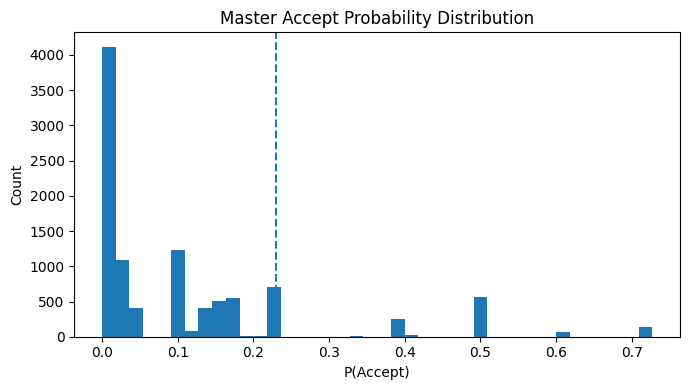

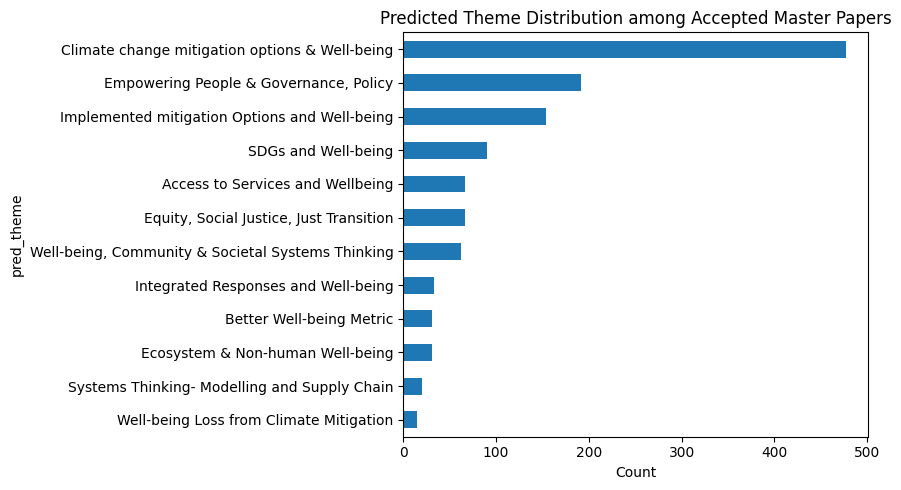

ZIP saved to: /kaggle/working/hybrid_specter_bge_tfidf_climate_outputs.zip


In [13]:
# ============================================================
# 9. Metrics, diagnostics, plots, and ZIP export
# ============================================================
stage1_metrics = binary_metrics(y, OOF_ACCEPT_PROB, final_accept_threshold)
stage2_metrics = theme_metrics(y_theme_all, OOF_THEME_PROB)

summary = {
    'excluded_models': ['ClimateBERT', 'DeBERTa'],
    'embedding_models_used': EMBEDDING_MODELS if DENSE_TRAIN.shape[1] > 0 else [],
    'n_training_rows': int(len(train_df)),
    'n_master_rows': int(len(master_df)),
    'n_accept_train': int(y.sum()),
    'train_accept_rate': float(train_accept_rate),
    'n_themes': int(N_THEMES),
    'stage1_oof_metrics': stage1_metrics,
    'stage1_raw_threshold': float(accept_threshold),
    'stage1_final_threshold_used': float(final_threshold_used),
    'stage1_master_accept_count': int(master_accept_final.sum()),
    'stage1_master_accept_rate': float(master_accept_final.mean()),
    'stage2_oof_metrics_accepted_only': stage2_metrics,
    'stage2_best_prior_alpha': float(BEST_THEME_ALPHA),
    'theme_distribution_master_predicted_accepted_only': out.loc[out.pred_decision == 'Accept', 'pred_theme'].value_counts().to_dict(),
}
with open(OUTPUT_DIR / 'run_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))

# Plots
plt.figure(figsize=(7,4))
plt.hist(master_p_full, bins=40)
plt.axvline(final_threshold_used, linestyle='--')
plt.title('Master Accept Probability Distribution')
plt.xlabel('P(Accept)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'master_accept_probability_histogram.png', dpi=200)
plt.show()

if (out['pred_decision'] == 'Accept').sum() > 0:
    plt.figure(figsize=(9,5))
    theme_counts = out.loc[out.pred_decision == 'Accept', 'pred_theme'].value_counts().sort_values()
    theme_counts.plot(kind='barh')
    plt.title('Predicted Theme Distribution among Accepted Master Papers')
    plt.xlabel('Count')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'master_theme_distribution.png', dpi=200)
    plt.show()

# Top review candidates
review = out.sort_values('review_priority_score', ascending=False).head(300)
review.to_csv(OUTPUT_DIR / 'top_human_review_candidates.csv', index=False)

# Zip all outputs
zip_path = OUTPUT_DIR.parent / 'hybrid_specter_bge_tfidf_climate_outputs.zip'
with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
    for p in OUTPUT_DIR.glob('*'):
        if p.is_file():
            z.write(p, arcname=p.name)
print('ZIP saved to:', zip_path)

## How to interpret the result

Use the output files in this order:

1. `run_summary.json` — the compact result summary.
2. `hybrid_oof_audit_predictions.csv` — out-of-fold evidence for the labelled dataset.
3. `accept_threshold_grid.csv` — shows why the final Accept threshold was chosen.
4. `hybrid_master_10k_annotated.csv/xlsx` — final annotation of the master file.
5. `top_human_review_candidates.csv` — rows that should be checked first by a human reviewer.

The pipeline is designed to avoid the earlier failure modes:

- no aggressive rare-theme oversampling;
- no one-vs-all "any vote wins" acceptance;
- no low fixed threshold like 0.30;
- no generative LLM label training;
- no dependence on ClimateBERT or DeBERTa;
- calibrated thresholding and deployment accept-rate guardrails.